# Работа с табличными данными

## 1. Pandas

**Pandas** — это одна из самых популярных библиотек Python для работы с табличными данными. Она предоставляет удобные 
структуры данных:
* **Series** — одномерный массив с индексами, похожий на колонку в таблице;
* **DataFrame** — двумерная таблица, где каждая колонка может иметь свой тип данных.

![pandas](../production/AI_Data_Analytics.Project_3.ID_1577559/misc/images/pandas.jpeg)

С помощью Pandas можно: фильтровать строки и столбцы, группировать данные, агрегировать показатели, объединять таблицы, 
работать с пропущенными значениями и строить простые визуализации. Владение Pandas — базовый и необходимый навык для 
проведения EDA.

In [1]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Задание 1.1. Загрузка данных
1. Пройди по ссылке на хранилище с датасетом [2025 Kaggle Machine Learning & Data Science Survey](https://disk.360.yandex.ru/d/ATLDXjTVorMf3Q).
3. Скачай CSV-файлы с данными и сохрани их в папку `datasets`.
4. С помощью библиотеки `pandas` загрузи:
   * таблицу с выбором ответов (multiple choice) в переменную `multiple`,
   * таблицу со свободными ответами (free form) `freeform`.
5. Выведи размеры каждой таблицы.
   
> **Важно:** загружать датасеты на Git не нужно.

In [2]:
freeform = pd.read_csv("../assets/project3/2025/freeform_responses.csv", low_memory=False)

In [3]:
multiple = pd.read_csv("../assets/project3/2025/multiple_choice_responses.csv", low_memory=False)

In [4]:
freeform.shape

(23860, 35)

In [5]:
multiple.shape

(23860, 394)

### Задание 1.2. Словарь вопросов
В таблицах `freeform` и `multiple`  первая строка содержит текстовые формулировки вопросов (например: *'What is your gender? — Selected Choice'*, *'What is your age (# years)?'* и т. д.), а сами данные начинаются со второй строки.

1. Создай структуру `name2question`, которая для каждой колонки содержит словарь с ключами `question` и `type`. В ключе `question` хранится текст вопроса, а в ключе `type` — тип таблицы, из которой пришел вопрос: `'multiple'`, `'freeform'` или `'both'` (если колонка есть в обеих таблицах).
```
name2question['Q1']
{'question': 'What is your gender? - Selected Choice', 'source': 'multiple'}
```

2. Выведи значение для вопроса `Q1_OTHER_TEXT` из структуры `name2question`.
3. Удали первые строки из таблиц `freeform` и `multiple`.
4. Выведи размерности таблиц `freeform` и `multiple`.

In [6]:
# 1. Создаем структуру name2question
name2question = {}

# Получаем первую строку из каждой таблицы (тексты вопросов)
multiple_questions = multiple.iloc[0]
freeform_questions = freeform.iloc[0]

# Получаем множества колонок для определения общих
multiple_cols = set(multiple.columns)
freeform_cols = set(freeform.columns)
all_cols = multiple_cols.union(freeform_cols)

# Заполняем словарь для каждой колонки
for col in all_cols:
    question_text = None
    source = None
    
    # Определяем источник и текст вопроса
    in_multiple = col in multiple_cols
    in_freeform = col in freeform_cols
    
    if in_multiple and in_freeform:
        source = 'both'
        # Если колонка есть в обеих таблицах, берем вопрос из multiple (или можно из freeform)
        question_text = multiple_questions[col]
    elif in_multiple:
        source = 'multiple'
        question_text = multiple_questions[col]
    elif in_freeform:
        source = 'freeform'
        question_text = freeform_questions[col]
    
    name2question[col] = {
        'question': question_text,
        'source': source
    }

# 2. Выводим значение для Q1_OTHER_TEXT
print("Значение для Q1_OTHER_TEXT:")
print(name2question['Q1_OTHER_TEXT'])

# 3. Удаляем первые строки из таблиц
freeform = freeform.iloc[1:].reset_index(drop=True)
multiple = multiple.iloc[1:].reset_index(drop=True)

# 4. Выводим размерности таблиц
print("\nРазмерность таблицы freeform:", freeform.shape)
print("Размерность таблицы multiple:", multiple.shape)

Значение для Q1_OTHER_TEXT:
{'question': 'What is your gender? - Prefer to self-describe - Text', 'source': 'both'}

Размерность таблицы freeform: (23859, 35)
Размерность таблицы multiple: (23859, 394)


### Задание 1.3. Анализ общих колонок

В таблице `multiple` некоторые колонки содержат числовые коды ответов. Если значение отлично от `-1`, это означает, что респондент выбрал свой вариант ответа, и в таблице `freeform` для той же строки (с тем же индексом) должно присутствовать соответствующее текстовое значение в свободной форме.

Проверить возможность корректного объединения таблиц `multiple` и `freeform`.

1. Определи общие колонки:
   - Найди все колонки, которые присутствуют одновременно в таблицах `multiple` и `freeform`.
   - Выведи их количество.

2. Проведи анализ общих колонок:
   - Выбери 2–3 общие колонки для детального изучения (например, `Q1_OTHER_TEXT`, `Q6_OTHER_TEXT`).
   - Для каждой выбранной колонки:
     - Выведи частоты значений в таблице `multiple` (количество значений, отличных от `-1`).
     - Выведи частоты значений в таблице `freeform` (количество непустых текстовых значений).
     - Найди индексы строк, где в таблице `multiple` значение отлично от `-1`.
     - Найди индексы строк, где в таблице `freeform` присутствуют текстовые значения.
     - Сравни эти два набора индексов.

3. Напиши свои выводы по результатам анализа:
   - Можно ли корректно объединить эти две таблицы по индексам строк?
   - Если нет, приведи конкретные примеры, демонстрирующие проблему (выведи соответствующие строки из обеих таблиц).

In [7]:
freeform_columns = set(freeform.columns)
multiple_columns = set(multiple.columns)

In [8]:
over_lapper_columns = list(freeform_columns.intersection(multiple_columns))
len(over_lapper_columns)

35

***Результаты анализа:***

просто так нельзя

### Задание 1.4. Объединение таблиц
В предыдущем задании мы выяснили, что таблицы `multiple` и `freeform` нельзя просто объединить по номерам строк — данные не совпадают. Но мы можем попробовать восстановить связи между числовыми кодами из `multiple` и текстовыми ответами из `freeform`.

Идея:
Если какое-то текстовое значение встречается в `freeform` определенное количество раз, и в `multiple` есть числовой код, который встречается такое же количество раз, причем эта частота уникальна (встречается только один раз в каждой таблице), то скорее всего это одно и то же значение.

Что нужно сделать:
1. Создай копию таблицы `multiple` и сохрани её в переменную `responses`.
2. Для каждой общей колонки:
   - Посчитай, сколько раз встречается каждое значение в `multiple` (не считай `-1` и пустые значения).
   - Посчитай, сколько раз встречается каждое значение в `freeform` (не считай пустые строки и пустые значения).
   - Найди пары, где:
     * Частота совпадает (например, и код, и текст встречаются по 7 раз)
     * Эта частота уникальна (встречается только один раз в каждой таблице)
   - Выполни замену значений в колонке таблицы `responses`:
     * Значения, которые были равны `-1`, оставь без изменений (`-1`).
     * Найденные числовые коды (для которых удалось найти соответствующее текстовое значение) замени на соответствующие текстовые значения из `freeform`.
     * Для всех остальных числовых кодов (которые не удалось сопоставить) замени на `-2`.
3. Подсчитай и выведи:
   - Средний процент текстовых значений из `freeform`, которые удалось успешно сопоставить с числовыми кодами из `multiple`, по всем колонкам **(в процентах)**.
   - Название колонки, для которой получилось сопоставить больше всего значений.

In [9]:
responses = multiple.copy()

In [10]:
result = []
for col in over_lapper_columns:
    asis = (multiple[col] != "-1").sum()
    multiple_counts = multiple[col].value_counts()
    multiple_counts = multiple_counts[
        (multiple_counts.index.astype(str) != "-1") & 
        (multiple_counts.index.notna())
    ]

    freeform_counts = freeform[col].value_counts()
    freeform_counts = freeform_counts[
        (freeform_counts.index.astype(str).str.strip() != '') & 
        (freeform_counts.index.notna())
    ]
    multiple_freq_counts = multiple_counts.value_counts()
    freeform_freq_counts = freeform_counts.value_counts()
    
    multiple_unique_freqs = set(multiple_freq_counts[multiple_freq_counts == 1].index)
    freeform_unique_freqs = set(freeform_freq_counts[freeform_freq_counts == 1].index)

    mapping = {"-1": "-1"}
    for numeric_code in multiple_counts.index:
        freq_multiple = multiple_counts[numeric_code]
        
        # Проверяем, что эта частота уникальна в multiple
        if freq_multiple in multiple_unique_freqs:
            # Ищем текстовое значение с такой же уникальной частотой в freeform
            if freq_multiple in freeform_unique_freqs:
                # Находим текстовое значение с такой частотой
                text_values_with_freq = freeform_counts[freeform_counts == freq_multiple]
                if len(text_values_with_freq) == 1:
                    # Нашли уникальное соответствие
                    text_value = text_values_with_freq.index[0]
                    mapping[numeric_code] = text_value
    responses[col] = responses[col].map(mapping).fillna("-2")
    tobe = ((responses[col] != "-1") & (responses[col] != "-2")).sum()
    result.append(tobe / asis)

In [11]:
np.array(result).mean() *100

21.411941905848455

In [12]:
max_index = np.argmax(result)
over_lapper_columns[max_index]

'Q34_OTHER_TEXT'

### Задание 1.5. Анализ пропусков
Мы объединили наши данные ответов в сводной форме. Давай проанализируем, насколько респондентам хватало предложенных вариантов ответа на вопросы. В опросе есть вопросы, где респонденты могли выбрать вариант из предложенных, а также написать свой ответ в свободной форме. Если респондент часто предпочитал сам давать ответы, это может указывать на то, что предложенные варианты были недостаточно полными.

1. Найди все **вопросы**, в которых встречаются колонки со свободным ответом. Исключи вопрос `Q12` в нем свободный ответ встерчается несколько раз. Выведи количество таких вопросов.

2. Среди этих вопросов найди:

   - Вопрос, на который респонеденты чаще всего не выбирали ответа из предложенных
   - Вопрос на котором респонденты всегда выбирали ответ из предложенного
   - Вопрос на который респонеденты чаще всего писали свободный ответ

In [13]:
### Задание 1.5. Анализ пропусков (обновлённое решение)

# 1. Собираем вопросы, у которых есть хотя бы одна колонка *_OTHER_TEXT
other_text_cols = [col for col in responses.columns if col.endswith('_OTHER_TEXT')]
free_questions = {col.split('_')[0] for col in other_text_cols}

# Исключаем Q12 (у него несколько *_OTHER_TEXT частей)
free_questions.discard('Q12')

print(f'Количество вопросов со свободным ответом (без Q12): {len(free_questions)}')

stats = []
total_rows = len(responses)

for question in sorted(free_questions):
    if question == 'Q1':
        select_cols = ['Q1']
        free_cols = ['Q1_OTHER_TEXT']
    else:
        select_cols = responses.columns[
            responses.columns.str.startswith(question) &
            ~responses.columns.str.contains('_TEXT')
        ].tolist()
        free_cols = responses.columns[
            responses.columns.str.startswith(question) &
            responses.columns.str.contains('_TEXT')
        ].tolist()

    if not free_cols or not select_cols:
        continue

    free_series = responses[free_cols[0]].astype(str)

    # Доля свободных ответов
    free_mask = (free_series != '-1') & (free_series.str.strip() != '')
    free_count = free_mask.sum()

    # Когда ответ из вариантов НЕ выбран (все варианты NaN/пусто)
    select_df = responses[select_cols]
    no_choice_mask = select_df.isna().all(axis=1)
    no_choice_count = no_choice_mask.sum()

    # Когда выбран хотя бы один предложенный вариант (допускаем числовые коды)
    # Используем notna, т.к. пустая строка для multiple-choice не встречается
    chosen_mask = select_df.notna().any(axis=1)
    always_choice = (~free_mask & chosen_mask).sum()

    stats.append({
        'question': question,
        'free_share': free_count / total_rows,
        'free_count': free_count,
        'no_choice': no_choice_count,
        'always_choice': always_choice
    })

# 2. Ищем нужные вопросы
if stats:
    q_max_free = max(stats, key=lambda x: x['free_share'])
    q_no_choice = max(stats, key=lambda x: x['no_choice'])
    q_always_choice = max(stats, key=lambda x: x['always_choice'])

    print('\nРезультат:')
    print(f"- Больше всего уходили в свободный текст: {q_max_free['question']} "
          f"({q_max_free['free_count']} ответов, доля {q_max_free['free_share']:.2%})")
    print(f"- Чаще всего игнорировали предложенные варианты: {q_no_choice['question']} "
          f"({q_no_choice['no_choice']} строк без выбора)")
    print(f"- Всегда выбирали из предложенных: {q_always_choice['question']} "
          f"({q_always_choice['always_choice']} строк только с выбором)")
else:
    print("Нет вопросов, удовлетворяющих условиям.")

Количество вопросов со свободным ответом (без Q12): 29

Результат:
- Больше всего уходили в свободный текст: Q34 (15937 ответов, доля 66.80%)
- Чаще всего игнорировали предложенные варианты: Q30 (19503 строк без выбора)
- Всегда выбирали из предложенных: Q1 (23780 строк только с выбором)


### Задание 1.6. Очистка респондентов

В данных есть информация о времени заполнения опроса. Логично предположить, что если респондент отвечал **слишком быстро** или, наоборот, **слишком долго**, такие ответы могут быть недостоверными. Для очистки данных воспользуемся методом выявления выбросов на основе **box plot**.

**Box plot (ящик с усами)** — это способ визуализации распределения данных. Внутри прямоугольника (ящика) находятся значения от 1-го до 3-го квартиля (Q1 и Q3), линия внутри — это медиана. «Усы» обычно определяются через **интерквартильный размах (IQR)**, который равен:

$$IQR = Q3 - Q1$$
Значения ниже $Q1 - 1.5 \times IQR$ и выше $Q3 + 1.5 \times IQR$ считаются выбросами.

1. Построй box plot для времени заполнения опроса. Ограничь ось **X** от 0 до 5000 секунд.
2. Рассчитай интерквартильный размах (IQR).
3. Выведи нижнюю и верхнюю границы интервала для выявления выбросов.
4. Так как нижняя граница получилась отрицательной, будем априорно считать минимальное адекватное время заполнения равным **2 минутам (120 секунд)**.
5. Отфильтруй DataFrame, оставив только респондентов с временем заполнения от 120 секунд до верхней границы.
6. Выведи размерность очищенного датасета.

In [14]:
responses["Time from Start to Finish (seconds)"] = responses["Time from Start to Finish (seconds)"].astype(int)

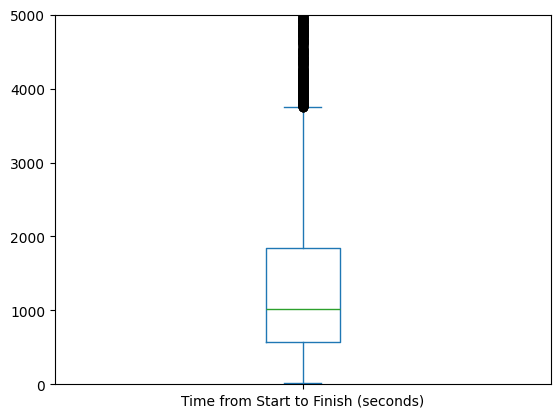

In [15]:
responses["Time from Start to Finish (seconds)"].plot.box()
plt.ylim(0, 5000)
plt.show();

In [16]:
Q1 = np.percentile(responses["Time from Start to Finish (seconds)"], 25)
Q3 = np.percentile(responses["Time from Start to Finish (seconds)"], 75)
IQR = Q3 - Q1
print(IQR)

1272.0


In [17]:
upper = Q3+1.5*IQR
print("Upper Bound:", upper)

lower = Q1-1.5*IQR
print("Lower Bound:", lower)

Upper Bound: 3750.0
Lower Bound: -1338.0


In [18]:
responses = responses[
    (responses["Time from Start to Finish (seconds)"] < upper) & 
    (responses["Time from Start to Finish (seconds)"] > 120)
]

In [19]:
responses.shape

(18696, 394)

### Задание 1.7. Второй язык
1. Проанализируй, какие языки программирования чаще всего используют респонденты в каждой профессии. Используй `groupby` и посмотри список языков программирования внутри каждой группы.
2. Для роли `Statistician` назови самый популярный язык.
3. Для роли `Student` укажи самый непопулярный язык.
4. Для роли `Data Engineer` найди второй по популярности язык.
5. Для роли `Data Scientist` определи пятый по популярности язык.


In [20]:
responses.groupby(["Q6", "Q17"]).size().sort_values(ascending=False).groupby("Q6").nth(0).loc["Statistician"]

Q17
R    81
dtype: int64

In [21]:
responses.groupby(["Q6", "Q17"]).size().sort_values(ascending=False).groupby("Q6").nth(-1).loc["Student"]

Q17
Julia    1
dtype: int64

In [22]:
responses.groupby(["Q6", "Q17"]).size().sort_values(ascending=False).groupby("Q6").nth(1).loc["Data Engineer"]

Q17
SQL    65
dtype: int64

In [23]:
responses.groupby(["Q6", "Q17"]).size().sort_values(ascending=False).groupby("Q6").nth(4).loc["Data Scientist"]

Q17
Java    35
dtype: int64

### Задание 1.8. Кто быстрее
Давай посмотрим, кто быстрее отвечает на вопросы в опросе в разрезе пол/возраст. Это может помочь понять, есть ли различия в подходе к заполнению опроса между разными группами респондентов.

Составь сводную таблицу в разрезе пол/возраст по среднему времени заполнения опроса. Рассматривай только респондентов с полом `Male` и `Female`.

1. Отфильтруй данные, оставив только респондентов с полом `Male` и `Female`.
2. Создай сводную таблицу, где:
   - строки — пол,
   - столбцы — возрастные группы,
   - значения — среднее время заполнения опроса.
3. Покрась зеленым цветом ячейку для каждого возрастного промежутка, где показано, кто быстрее заполнил опросник (мужчины или женщины).
4. Выведи полученную сводную таблицу и её размерность.


In [24]:
# 1. Отфильтруем данные, оставив только респондентов с полом Male и Female
filtered_responses = responses[responses['Q1'].isin(['Male', 'Female'])]

In [ ]:
# 2. Создаем сводную таблицу, где строки - пол (Q1), столбцы - возрастные группы (Q2), значения - среднее время заполнения опроса
pivot_table = pd.pivot_table(
    filtered_responses, 
    values="Time from Start to Finish (seconds)", 
    index=["Q1"],  # строки - пол
    columns=["Q2"],  # столбцы - возрастные группы
    aggfunc="mean"
)

In [ ]:
# 3. Функция для покраски зеленым цветом ячейки с минимальным значением (кто быстрее) в каждом столбце (возрастной группе)
def highlight_faster(s):
    """Покрасить зеленым ячейку с минимальным значением (кто быстрее заполнил)"""
    is_min = s == s.min()
    return ['background-color: lightgreen' if min_val else '' for min_val in is_min]

# Применяем стилизацию по столбцам (axis=0), чтобы для каждого возрастного промежутка найти, кто быстрее
styled_table = pivot_table.style.apply(highlight_faster, axis=0)
styled_table

Q1,Female,Male
Q2,,
18-21,759.520202,911.596608
22-24,988.058971,991.956343
25-29,1035.078704,1085.422807
30-34,1040.801619,1124.884901
35-39,1160.692029,1206.624147
40-44,1096.919708,1205.302198
45-49,1157.102273,1244.483108
50-54,1199.907407,1250.489051
55-59,1217.068966,1226.064935


In [27]:
# 4. Выводим полученную сводную таблицу и её размерность
print("Сводная таблица:")
print(pivot_table)
print(f"\nРазмерность таблицы: {pivot_table.shape}")

Сводная таблица:
Q1          Female         Male
Q2                             
18-21   759.520202   911.596608
22-24   988.058971   991.956343
25-29  1035.078704  1085.422807
30-34  1040.801619  1124.884901
35-39  1160.692029  1206.624147
40-44  1096.919708  1205.302198
45-49  1157.102273  1244.483108
50-54  1199.907407  1250.489051
55-59  1217.068966  1226.064935
60-69  1572.300000  1259.247748
70-79  2041.500000  1359.400000
80+     139.000000  1570.333333

Размерность таблицы: (12, 2)


In [28]:
responses.to_csv("../assets/project4/kaggle_survey_2025_responses_v1.csv")

In [29]:
with open("../assets/project4/name2question.json", 'w') as fout:
    json.dump(name2question, fout, indent=4)